# Actividad 2 - Procesamiento de imágenes aplicado a una imagen GPS

**Nombre: Javiera Vega Pino**  
**ID: 21079241-4**  
**Fecha: 23 de mayo de 2026**  

En esta actividad se trabaja con una imagen tipo mapa que contiene una trayectoria GPS degradada. El objetivo es aplicar herramientas básicas de procesamiento de imágenes: visualización, histograma, filtrado, estimación/remoción de fondo y transformada wavelet 2D tipo Haar.

**Importante:** esta actividad no incluye análisis de series temporales, predicción lineal, clasificación ni métricas de detección de objetos. Es una actividad corta de preparación para el Proyecto II.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pywt  # para transformada Haar 2D
from scipy.ndimage import gaussian_filter, median_filter #para los filtros espaciales

## 1. Leer un caso y visualizar la información disponible

Seleccione uno de los casos del conjunto de datos. Cargue y visualice:

- `map_background.png`,
- `gps_trace_clean.png`,
- `gps_trace_noisy.png`,
- `gps_trace_overlay.png`.

Explique brevemente qué información contiene cada imagen.

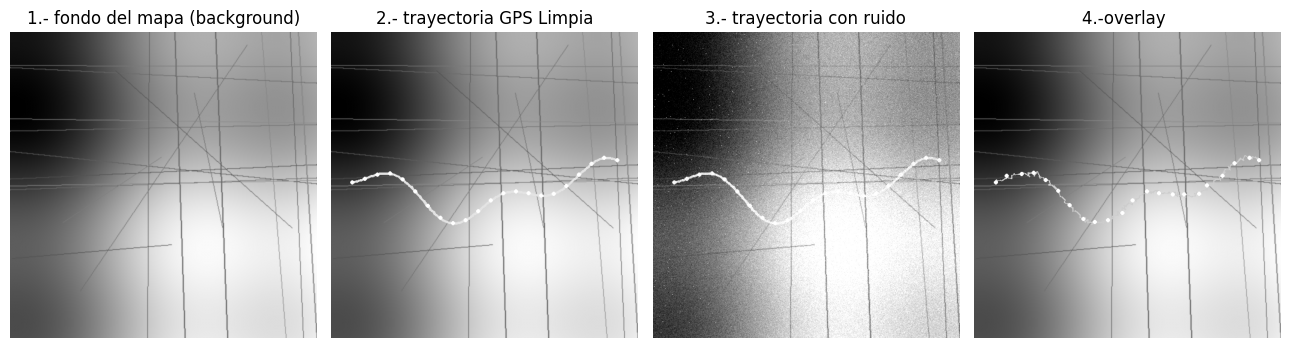

Se seleccionó el segundo caso.
La imagen (1) muestra solamente el fondo del mapa sin ninguna trayectoria.
La imagen (2) muestra la ruta limpia y óptima con la imagen (1) de fondo.
La imagen (3) muestra la misma trayectoria anterior pero con ruido de tipo "sal y pimienta" incluido
La imagen (4) muestra la superposición de la trayectoria en la imagen de fondo (1). Es la referencia del trabajo.


In [146]:
#cargar y mostrar todas las imagenes
fondo_mapa = plt.imread('map_background.png')
gps_limpia = plt.imread('gps_trace_clean.png')
gps_ruido = plt.imread('gps_trace_noisy.png')
img_overlay = plt.imread('gps_trace_overlay.png') 
fig, axs = plt.subplots(1, 4, figsize=(13, 7)) 

#cmap='gray' para visualizar las imágenes igual que las originales, de lo contrario la librería automáticamente las muestra a color 
axs[0].imshow(fondo_mapa, cmap='gray')
axs[0].set_title('1.- fondo del mapa (background)')
axs[0].axis('off')

axs[1].imshow(gps_limpia, cmap='gray')
axs[1].set_title('2.- trayectoria GPS Limpia')
axs[1].axis('off')

axs[2].imshow(gps_ruido, cmap='gray')
axs[2].set_title('3.- trayectoria con ruido')
axs[2].axis('off')

axs[3].imshow(img_overlay, cmap='gray')
axs[3].set_title('4.-overlay ')
axs[3].axis('off')
    
plt.tight_layout()
plt.show()

print('Se seleccionó el segundo caso.\n'
'La imagen (1) muestra solamente el fondo del mapa sin ninguna trayectoria.\n' \
'La imagen (2) muestra la ruta limpia y óptima con la imagen (1) de fondo.\n' \
'La imagen (3) muestra la misma trayectoria anterior pero con ruido de tipo "sal y pimienta" incluido\n' \
'La imagen (4) muestra la superposición de la trayectoria en la imagen de fondo (1). Es la referencia del trabajo.')

## 2. Histograma de intensidad

Calcule y grafique el histograma de intensidad de `gps_trace_noisy.png`.

Discuta:

- qué rango de intensidades parece corresponder al fondo,
- qué rango podría corresponder a la trayectoria o a estructuras brillantes,
- por qué el histograma es útil antes de aplicar un umbral o una corrección de contraste.

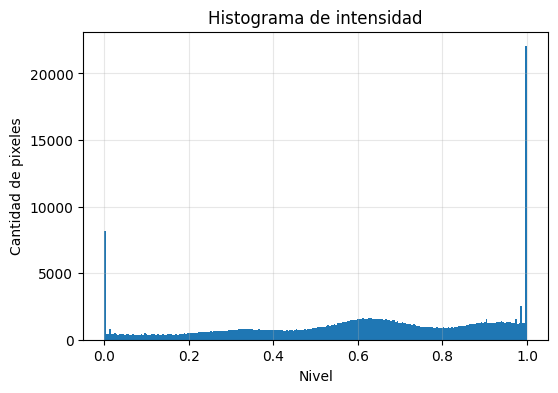

El histograma va de 0 a 255 (en este caso hay 256 bins que se representan en una escala de 0 a 1), en el cual el fondo
abarca la mayoría del gráfico (app de 0.1 a 0.9) lo cual equivale a tonos entre 25 y 215 que indican que hay distintas iluminaciones
en la imagen. Además, el rango que corresponde a estructuras brillantes o trayectorias son los colores blanco y negro puros y se asocian
a los peaks en los valores 0 y 1 (equivalente a 0 y 255)

El histograma es útil antes de aplicar un umbral o una corrección de contraste porque sirve para decidir donde y cómo aplicar estrategias
para separar el ruido de la imagen, por ejemplo en este caso para corrección de contraste se confirma que la mejor opcion es usar filtros
espaciales gracias a los peak de ruido en los extremos y también ayuda para aplicar el umbral ya que este se cortaría en los valores cercanos a 0 y 1. 


In [142]:
arreglo_ruido = gps_ruido.flatten() #pasar de 2D a 1D el arreglo

plt.figure(figsize=(6, 4))
plt.hist(arreglo_ruido, bins=256, alpha=1) #histograma con 256 =todos los niveles de "gris" que hay en la imagen

plt.title('Histograma de intensidad')
plt.xlabel('Nivel')
plt.ylabel('Cantidad de pixeles')
plt.grid(True, alpha=0.3)
plt.show()

print('El histograma va de 0 a 255 (en este caso hay 256 bins que se representan en una escala de 0 a 1), en el cual el fondo\n' \
'abarca la mayoría del gráfico (app de 0.1 a 0.9) lo cual equivale a tonos entre 25 y 215 que indican que hay distintas iluminaciones\n' \
'en la imagen. Además, el rango que corresponde a estructuras brillantes o trayectorias son los colores blanco y negro puros y se asocian\n' \
'a los peaks en los valores 0 y 1 (equivalente a 0 y 255)\n'
'\n' \
'El histograma es útil antes de aplicar un umbral o una corrección de contraste porque sirve para decidir donde y cómo aplicar estrategias\n' \
'para separar el ruido de la imagen, por ejemplo en este caso para corrección de contraste se confirma que la mejor opcion es usar filtros\n' \
'espaciales gracias a los peak de ruido en los extremos y también ayuda para aplicar el umbral ya que este se cortaría en los valores cercanos a 0 y 1. ')

## 3. Filtro gaussiano y filtro de mediana

Aplique un filtro gaussiano y un filtro de mediana a la imagen degradada.

Compare ambos resultados y explique:

- cuál reduce mejor el ruido suave,
- cuál es más efectivo frente a píxeles impulsivos,
- qué efectos no deseados pueden aparecer sobre bordes o estructuras delgadas.

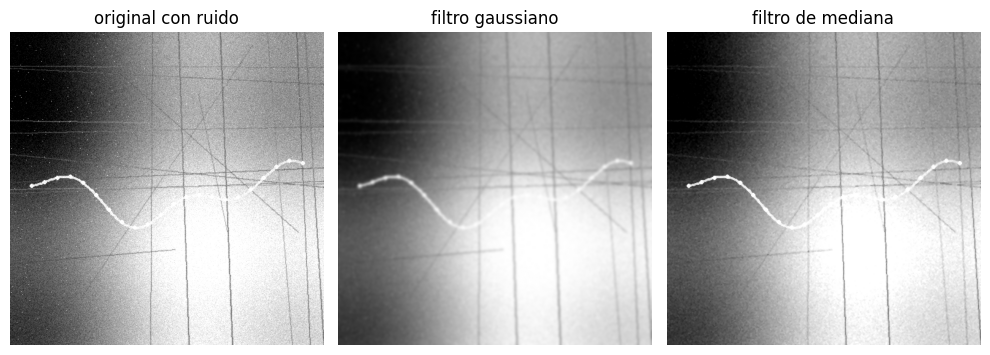

Se observa que respecto al ruido suave y a los píxeles impulsivos, el filtro gaussiano difumina el ruido y además detalles importantes
de la imagen como la trayectoria, lo cual no es ideal. A diferencia del filtro de mediana, el cual elimina el ruido pero mantiene en su mayoría
los detalles importantes de la imagen tales como el fondo del mapa y la trayectoria.
Por lo tanto el filtro más adecuado para este caso es el filtro de mediana.

En este caso el filtro gaussiano produce efectos no deseados en los bordes y estructuras delgadas, ya que, difumina todos los bordes que tengan
mayor contraste, por lo que hace que la imagen pierda mucha nitudez y la trayectoria y el fondo del mapa se difuminen.


In [143]:
filt_gaussiano = gaussian_filter(gps_ruido, sigma=2) # filtro gaussiano con desviacion estándar =2

filt_mediana = median_filter(gps_ruido, size=3) #filtro de mediana con ventana estándar de 3x3

fig, axs = plt.subplots(1, 3, figsize=(10, 8))
axs[0].imshow(gps_ruido, cmap='gray')
axs[0].set_title('original con ruido')
axs[0].axis('off')

axs[1].imshow(filt_gaussiano, cmap='gray')
axs[1].set_title('filtro gaussiano')
axs[1].axis('off')

axs[2].imshow(filt_mediana, cmap='gray')
axs[2].set_title('filtro de mediana')
axs[2].axis('off')
    
plt.tight_layout()
plt.show()

print('Se observa que respecto al ruido suave y a los píxeles impulsivos, el filtro gaussiano difumina el ruido y además detalles importantes\n' \
'de la imagen como la trayectoria, lo cual no es ideal. A diferencia del filtro de mediana, el cual elimina el ruido pero mantiene en su mayoría\n' \
'los detalles importantes de la imagen tales como el fondo del mapa y la trayectoria.\n' \
'Por lo tanto el filtro más adecuado para este caso es el filtro de mediana.\n' \
'\n' \
'En este caso el filtro gaussiano produce efectos no deseados en los bordes y estructuras delgadas, ya que, difumina todos los bordes que tengan\n' \
'mayor contraste, por lo que hace que la imagen pierda mucha nitudez y la trayectoria y el fondo del mapa se difuminen.')


## 4. Estimación y remoción de fondo

Estime un fondo suave $B(x,y)$ usando un filtro de gran escala. Luego calcule

$$
I_{\mathrm{corr}}(x,y)=I(x,y)-B(x,y).
$$

Muestre la imagen original degradada, el fondo estimado y la imagen corregida.

Según los resultados del inciso anterior, se seleccionó el filtro de mediana para generar la imagen corregida.


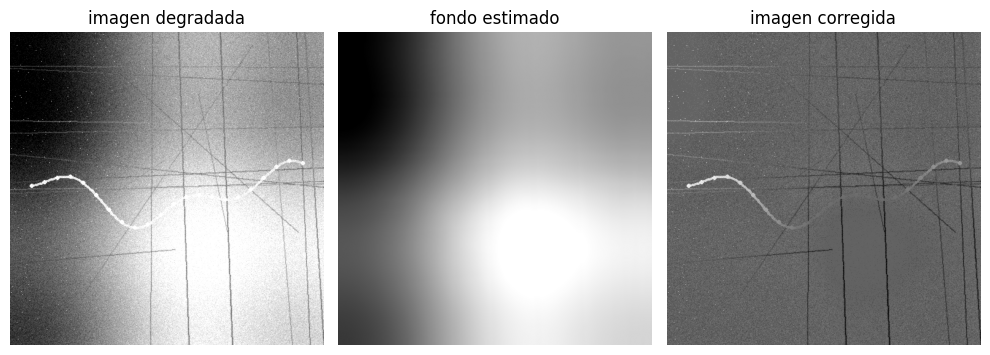

Se analizó de manera extra que, al estar trabajando con fondos de imagen generados por filtros de
gran escala, sin importar qué filtro se use (en este caso gaussiano) se obienen resultados muy similares. 


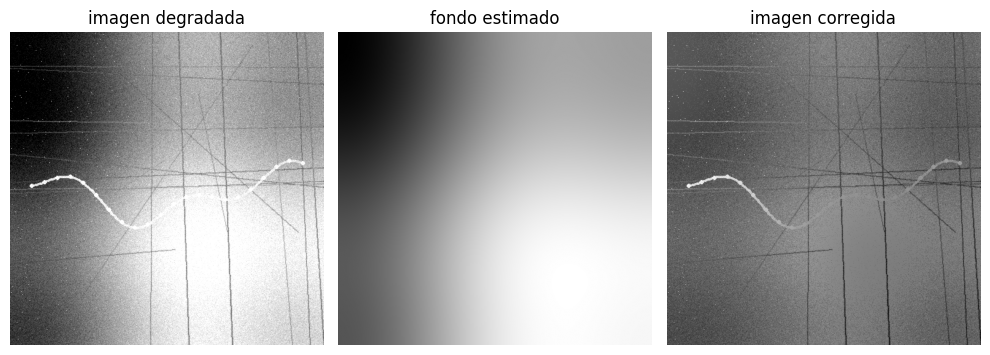

In [144]:
print('Según los resultados del inciso anterior, se seleccionó el filtro de mediana para generar la imagen corregida.')
fondo = median_filter(gps_ruido, size= 80) #filtro de gran escala para crear el fondo

corregida = gps_ruido - fondo #imagen corregida

fig, axs = plt.subplots(1, 3, figsize=(10, 8))
axs[0].imshow(gps_ruido, cmap='gray')
axs[0].set_title('imagen degradada')
axs[0].axis('off')

axs[1].imshow(fondo, cmap='gray')
axs[1].set_title('fondo estimado')
axs[1].axis('off')

axs[2].imshow(corregida, cmap='gray')
axs[2].set_title('imagen corregida')
axs[2].axis('off')

plt.tight_layout()
plt.show()

#Extra

print('Se analizó de manera extra que, al estar trabajando con fondos de imagen generados por filtros de\n' \
'gran escala, sin importar qué filtro se use (en este caso gaussiano) se obienen resultados muy similares. ')
fondo1 = gaussian_filter(gps_ruido, sigma= 90)
corregida1 = gps_ruido - fondo1 #imagen corregida

fig, axs = plt.subplots(1, 3, figsize=(10, 8))
axs[0].imshow(gps_ruido, cmap='gray')
axs[0].set_title('imagen degradada')
axs[0].axis('off')

axs[1].imshow(fondo1, cmap='gray')
axs[1].set_title('fondo estimado')
axs[1].axis('off')

axs[2].imshow(corregida1, cmap='gray')
axs[2].set_title('imagen corregida')
axs[2].axis('off')

plt.tight_layout()
plt.show()

## 5. Transformada wavelet 2D tipo Haar

Implemente o aplique una transformada Haar 2D de un nivel para obtener las subbandas:

$$
I(x,y) \rightarrow \{LL,LH,HL,HH\}.
$$

Muestre las cuatro subbandas y reconstruya la imagen. Verifique visualmente que la reconstrucción sea consistente.

LL:es la aproximacion de la imagen original
LH:son los detalles horizontales de la imagen
HL:son los detalles verticales de la imagen
HH:son los detalles diagonales de la imagen (concentración de ruido)


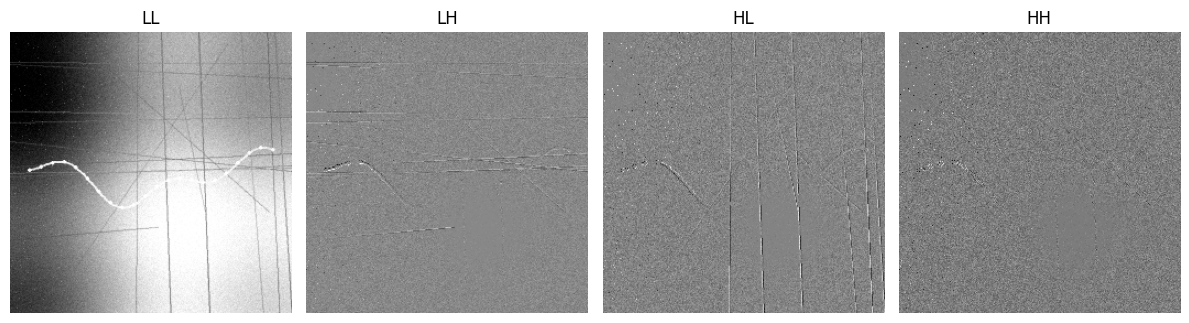

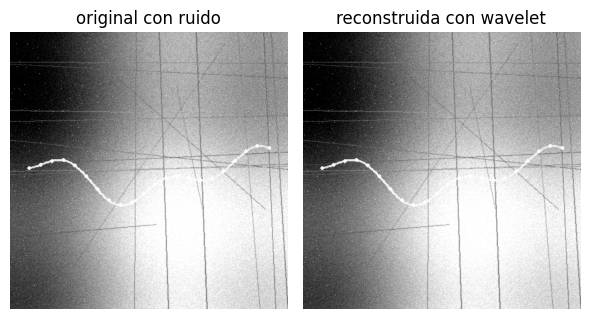

Se confirma visualmente que la reconstrucción de la imagen mediante transformada wavelet inversa es consistente


In [145]:
#basado en "01_single_level_haar_coefficients.py" y "03_reconstruction_from_coefficients.py"
wavelet = 'haar'
coef_2D = pywt.dwt2(gps_ruido, wavelet)

LL,( LH, HL, HH) = coef_2D # extraer subbandas

fig, axs = plt.subplots(1, 4, figsize=(12, 6))  # plot de las subbandas
axs[0].imshow(LL, cmap='gray')
axs[0].set_title('LL')
axs[0].axis('off')
print('LL:es la aproximacion de la imagen original')

axs[1].imshow(LH, cmap='gray')
axs[1].set_title('LH')
axs[1].axis('off')
print('LH:son los detalles horizontales de la imagen')

axs[2].imshow(HL, cmap='gray')
axs[2].set_title('HL')
axs[2].axis('off')
print('HL:son los detalles verticales de la imagen')

axs[3].imshow(HH, cmap='gray')
axs[3].set_title('HH')
axs[3].axis('off')
print('HH:son los detalles diagonales de la imagen (concentración de ruido)')

plt.tight_layout()
plt.show()

reconstruida = pywt.idwt2(coef_2D, wavelet) # reconstrucción  de la imagen con transformada inversa

fig, axs = plt.subplots(1, 2, figsize=(6, 4)) #comparación visual
axs[0].imshow(gps_ruido, cmap='gray')
axs[0].set_title('original con ruido')
axs[0].axis('off')

axs[1].imshow(reconstruida, cmap='gray')
axs[1].set_title('reconstruida con wavelet')
axs[1].axis('off')

plt.tight_layout()
plt.show()
print('Se confirma visualmente que la reconstrucción de la imagen mediante transformada wavelet inversa es consistente')

## 6. Comentario final

Escriba un comentario breve sobre qué herramienta fue más útil para mejorar la imagen y qué dificultad encontró al procesarla.

A lo largo del trabajo, la herramienta que demostró ser más útil fue el filtro de mediana, ya que, en este caso específico permitió eliminar el ruido de la imagen sin la necesidad de perder resolución y/o eliminar elementos importantes dentro de la imagen. No así el filtro gaussiano, ya que este suavizó las imágenes sin distinguir entre ruido y trayectorias. Pero también se concluye que en el caso de estar trabajando con filtros de gran escala, independiente del que se use, se obtendrán resultados similares ya que la imagen se suaviza de manera excesiva y ningún filtro podrá separar bien el ruido de los detalles que sí importan con un orden tan alto.

 Además, la transformada wavelet permitió observar y conocer cómo se distribuye la información dentro de la imagen, las dominancias del ruido impulsivo en todas las subbandas, mientras que en la LL se retiene la forma original. Lo mas difícil fue encontrar los parámetros exactos de los filtros para que mostraran resultados deseados, tales como el sigma en el filtro gaussiano y el tamaño del arreglo en el filtro de mediana, ya que, estos irán variando según el objetivo que se quiera lograr en la imagen (generar un fondo, eliminar un color específico, quitar ruido, etc).